# Prédiction du risque de maladie cardiaque — notebook final

## Objectif du projet

L'objectif de ce projet est de prédire le risque de maladie cardiaque à partir du dataset **UCI Heart Disease**, en comparant plusieurs stratégies de prétraitement et plusieurs modèles de classification.

Ce notebook constitue la **version de rendu** du travail. Il regroupe :
- la présentation et l'exploration du jeu de données ;
- les choix de prétraitement ;
- la comparaison de plusieurs méthodes d'imputation ;
- l'évaluation de plusieurs modèles de classification ;
- l'analyse finale des résultats.

L'enjeu méthodologique principal est double :
1. **fusionner proprement les quatre sources** du dataset ;
2. **évaluer l'impact du traitement des valeurs manquantes** sur les performances de prédiction.


## Plan du notebook

Le notebook suit la structure suivante :

1. chargement et présentation des données ;
2. analyse exploratoire (EDA) ;
3. prétraitement et définition des scénarios ;
4. comparaison des modèles sur un jeu d'entraînement via validation croisée ;
5. évaluation finale sur un jeu de test tenu à l'écart ;
6. ajustement du seuil de décision pour privilégier le rappel ;
7. diagnostics détaillés et conclusion.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11


## 1. Chargement des données

Nous utilisons ici les fichiers **processed** du dataset UCI Heart Disease. Ce choix est justifié par leur structure tabulaire plus simple :  
- **une ligne = un patient** ;
- **une colonne = une variable**.

Cela permet de travailler directement sur les 14 variables classiques du jeu de données, sans devoir reconstruire les observations à partir des fichiers bruts historiques.


In [2]:
# Recherche robuste du dossier contenant les fichiers processed
candidate_dirs = [
    Path.cwd(),
    Path.cwd() / "data",
    Path.cwd().parent / "data",
]

files = {
    "cleveland": "processed.cleveland.data",
    "hungarian": "processed.hungarian.data",
    "switzerland": "processed.switzerland.data",
    "va": "processed.va.data",
}

DATA_DIR = None
for directory in candidate_dirs:
    if all((directory / filename).exists() for filename in files.values()):
        DATA_DIR = directory
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Impossible de trouver les fichiers processed. "
        "Placez-les dans le dossier courant ou dans un sous-dossier 'data'."
    )

column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "num"
]

dfs = []
for source, filename in files.items():
    df_source = pd.read_csv(
        DATA_DIR / filename,
        header=None,
        names=column_names,
        na_values="?"
    )
    df_source["source"] = source
    dfs.append(df_source)

df = pd.concat(dfs, ignore_index=True)

print(f"Dossier utilisé : {DATA_DIR}")
print(f"Dimensions du jeu fusionné : {df.shape}")
display(df.head())


Dossier utilisé : c:\Users\titou\DOSSIER\ENSAI\Erasmus\cours\MachineLearning2\projetML2\code_projetML2\data
Dimensions du jeu fusionné : (920, 15)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,source
0,63.000,1.000,1.000,145.000,233.000,1.000,2.000,150.000,0.000,2.300,3.000,0.000,6.000,0,cleveland
1,67.000,1.000,4.000,160.000,286.000,0.000,2.000,108.000,1.000,1.500,2.000,3.000,3.000,2,cleveland
2,67.000,1.000,4.000,120.000,229.000,0.000,2.000,129.000,1.000,2.600,2.000,2.000,7.000,1,cleveland
3,37.000,1.000,3.000,130.000,250.000,0.000,0.000,187.000,0.000,3.500,3.000,0.000,3.000,0,cleveland
4,41.000,0.000,2.000,130.000,204.000,0.000,2.000,172.000,0.000,1.400,1.000,0.000,3.000,0,cleveland


## 2. Présentation générale du dataset

Les 13 variables explicatives décrivent des caractéristiques cliniques classiques en cardiologie (âge, tension au repos, cholestérol, fréquence cardiaque maximale, angine induite par l'effort, etc.). La variable cible `num` mesure la présence et le niveau de gravité de la maladie cardiaque :

- `0` : absence de maladie ;
- `1` à `4` : présence de la maladie avec sévérité croissante.

Dans la suite, nous étudierons donc :
- une **version binaire** de la cible (`0` vs `1-4`) ;
- une **version multiclasse** conservant les 5 modalités d'origine.


In [3]:
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (100 * df.isna().mean()).round(1),
    "n_unique": df.nunique(dropna=True),
})
display(overview)


,dtype,n_missing,pct_missing,n_unique
age,float64,0,0.000,50
sex,float64,0,0.000,2
cp,float64,0,0.000,4
trestbps,float64,59,6.400,61
chol,float64,30,3.300,217
fbs,float64,90,9.800,2
restecg,float64,2,0.200,3
thalach,float64,55,6.000,119
exang,float64,55,6.000,2
oldpeak,float64,62,6.700,53


In [4]:
source_counts = df["source"].value_counts().rename_axis("source").to_frame("n_obs")
source_counts["part"] = (source_counts["n_obs"] / len(df)).round(3)

target_counts = df["num"].value_counts().sort_index().rename_axis("num").to_frame("n_obs")
target_counts["part"] = (target_counts["n_obs"] / len(df)).round(3)

binary_target = (df["num"] > 0).astype(int)
binary_counts = binary_target.value_counts().sort_index().rename_axis("target_binary").to_frame("n_obs")
binary_counts["part"] = (binary_counts["n_obs"] / len(df)).round(3)

display(source_counts)
display(target_counts)
display(binary_counts)


,n_obs,part
source,,
cleveland,303,0.329
hungarian,294,0.320
va,200,0.217
switzerland,123,0.134


,n_obs,part
num,,
0,411,0.447
1,265,0.288
2,109,0.118
3,107,0.116
4,28,0.030


,n_obs,part
target_binary,,
0,411,0.447
1,509,0.553


### Commentaire

Après fusion, le dataset contient **920 patients** répartis entre les quatre sources : Cleveland (**303**), Hungary (**294**), VA Long Beach (**200**) et Switzerland (**123**).  
La cible multiclasse reste exploitable, mais elle est déséquilibrée : la classe `0` domine (**411 observations**) tandis que la classe `4` est rare (**28 observations**).

En binaire, on obtient **411 patients sains** contre **509 patients atteints**, ce qui rend le problème relativement équilibré et plus favorable à une modélisation robuste.


## 3. Analyse des valeurs manquantes

L'EDA doit d'abord caractériser la qualité de l'information disponible. Ici, le point central est l'hétérogénéité des valeurs manquantes : certaines variables sont presque complètes, d'autres sont très lacunaires et leur disponibilité dépend fortement de la source.


,pct_missing
ca,66.400
thal,52.800
slope,33.600
fbs,9.800
oldpeak,6.700
trestbps,6.400
thalach,6.000
exang,6.000
chol,3.300
restecg,0.200


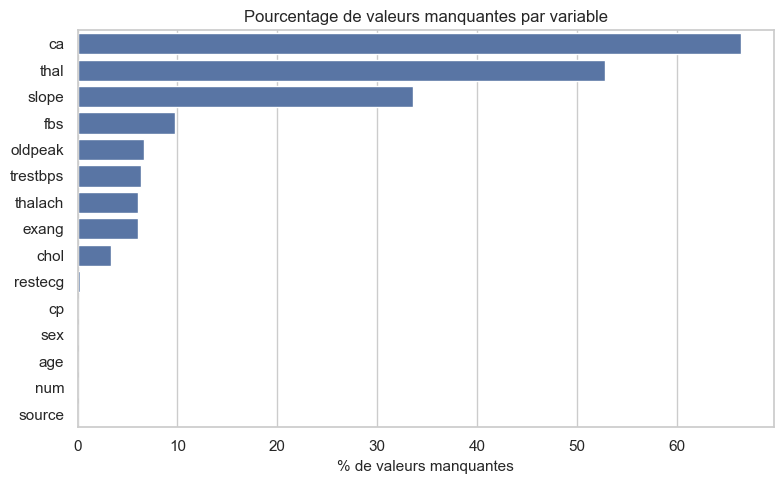

In [5]:
missing_table = (
    df.isna()
      .mean()
      .sort_values(ascending=False)
      .rename("pct_missing")
      .mul(100)
      .round(1)
      .to_frame()
)
display(missing_table)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=missing_table["pct_missing"], y=missing_table.index, ax=ax)
ax.set_title("Pourcentage de valeurs manquantes par variable")
ax.set_xlabel("% de valeurs manquantes")
ax.set_ylabel("")
plt.tight_layout()


source,cleveland,hungarian,switzerland,va
age,0.000,0.000,0.000,0.000
sex,0.000,0.000,0.000,0.000
cp,0.000,0.000,0.000,0.000
trestbps,0.000,0.300,1.600,28.000
chol,0.000,7.800,0.000,3.500
fbs,0.000,2.700,61.000,3.500
restecg,0.000,0.300,0.800,0.000
thalach,0.000,0.300,0.800,26.500
exang,0.000,0.300,0.800,26.500
oldpeak,0.000,0.000,4.900,28.000


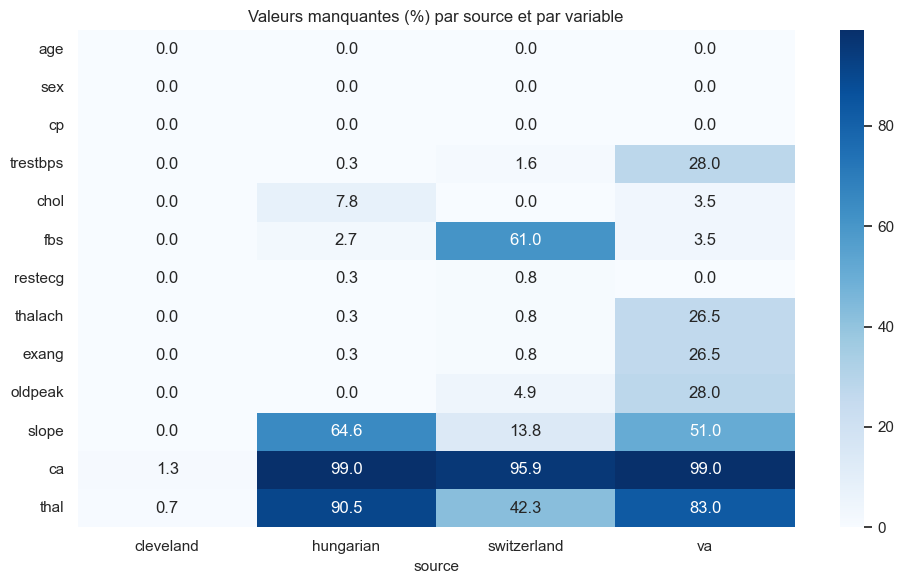

In [6]:
feature_columns = [col for col in column_names if col != "num"]

source_missing = (
    df.groupby("source")[feature_columns]
      .agg(lambda s: s.isna().mean())
      .T
      .mul(100)
      .round(1)
)
display(source_missing)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(source_missing, annot=True, fmt=".1f", cmap="Blues", ax=ax)
ax.set_title("Valeurs manquantes (%) par source et par variable")
plt.tight_layout()


### Commentaire

Les variables les plus problématiques sont clairement :
- `ca` : **66.4 %** de valeurs manquantes ;
- `thal` : **52.8 %** ;
- `slope` : **33.6 %**.

Cette difficulté n'est pas homogène selon les hôpitaux. Par exemple, `ca` est presque entièrement manquante dans Hungary, Switzerland et VA Long Beach, alors qu'elle est presque complète dans Cleveland. Cela justifie pleinement la comparaison de plusieurs stratégies d'imputation, plutôt que l'utilisation d'un unique prétraitement.


## 4. Analyse de la cible et des différences entre sources

La fusion des bases augmente la taille d'échantillon, mais elle introduit aussi un **effet de site** potentiel. Il faut donc vérifier si les distributions de la cible sont comparables entre sources.


num,0,1,2,3,4
source,,,,,
cleveland,0.541,0.182,0.119,0.116,0.043
hungarian,0.639,0.361,0.000,0.000,0.000
switzerland,0.065,0.390,0.260,0.244,0.041
va,0.255,0.280,0.205,0.210,0.050


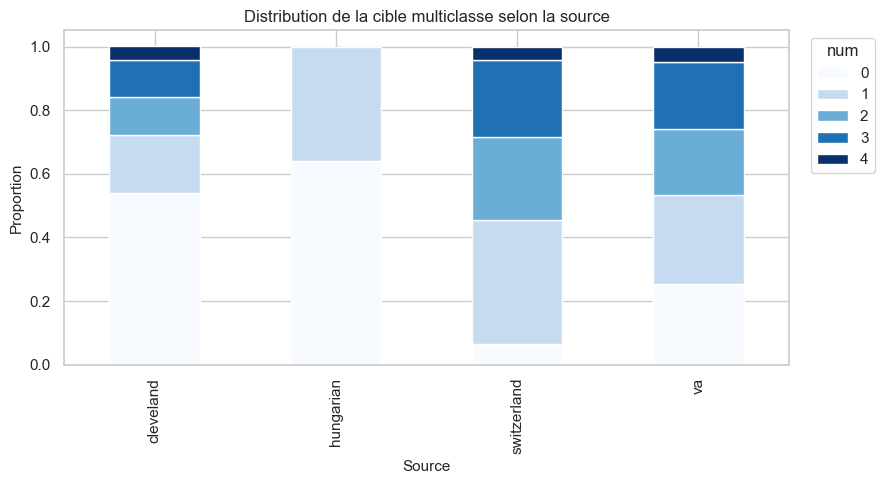

In [7]:
source_target = pd.crosstab(df["source"], df["num"], normalize="index").round(3)
display(source_target)

fig, ax = plt.subplots(figsize=(9, 5))
source_target.plot(kind="bar", stacked=True, ax=ax, colormap="Blues")
ax.set_title("Distribution de la cible multiclasse selon la source")
ax.set_xlabel("Source")
ax.set_ylabel("Proportion")
ax.legend(title="num", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()


### Commentaire

Les profils par hôpital sont très contrastés :
- **Hungary** contient surtout des patients en classe `0` ou `1` ;
- **Switzerland** contient très peu de patients sains ;
- **VA Long Beach** est plus répartie entre les classes ;
- **Cleveland** reste la source la plus équilibrée.

Cette hétérogénéité doit être gardée en tête au moment d'interpréter les performances des modèles : une bonne prédiction peut parfois refléter des différences entre sources et non uniquement des signaux cliniques.


## 5. Analyse univariée rapide

On distingue deux types de variables :
- des variables **quantitatives** : `age`, `trestbps`, `chol`, `thalach`, `oldpeak` ;
- des variables **catégorielles** codées numériquement : `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`.


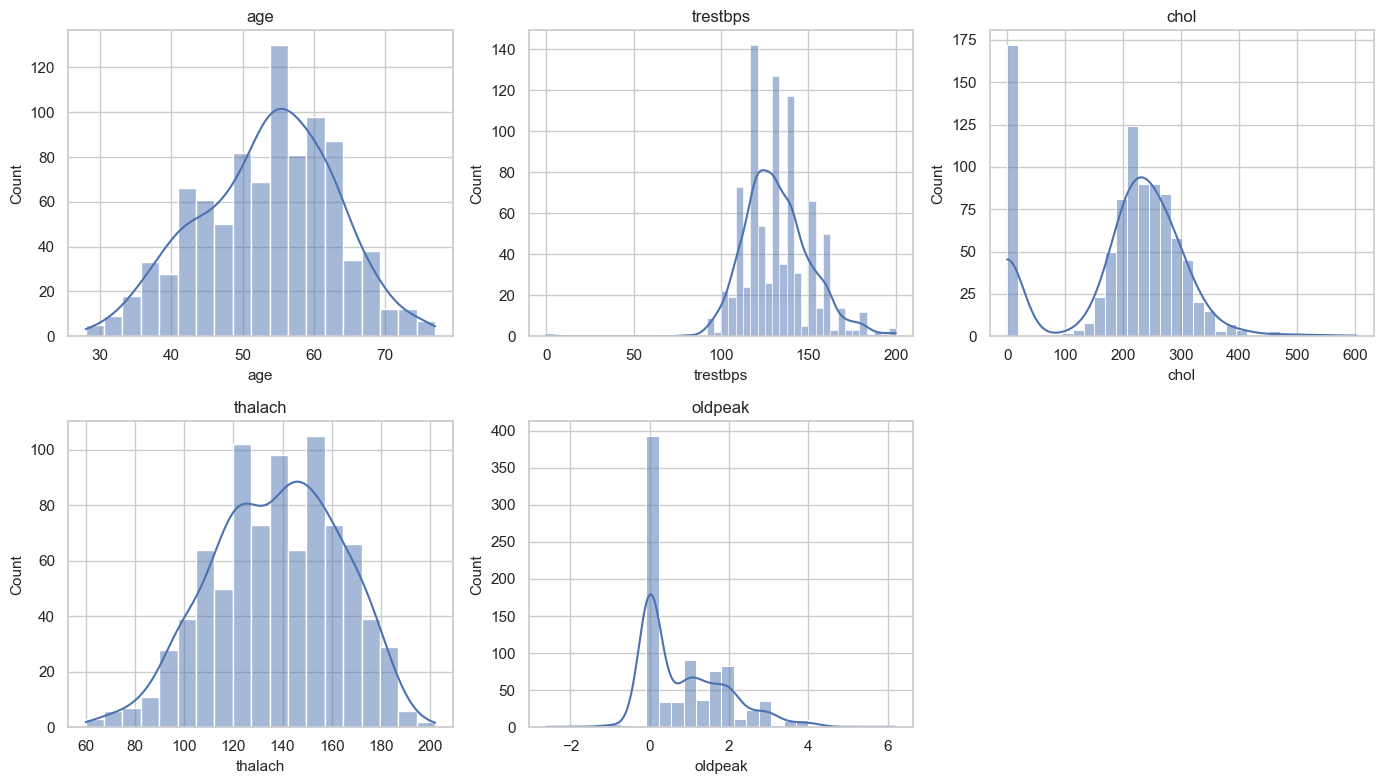

In [8]:
quantitative_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, col in zip(axes, quantitative_features):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)

for ax in axes[len(quantitative_features):]:
    ax.set_visible(False)

plt.tight_layout()


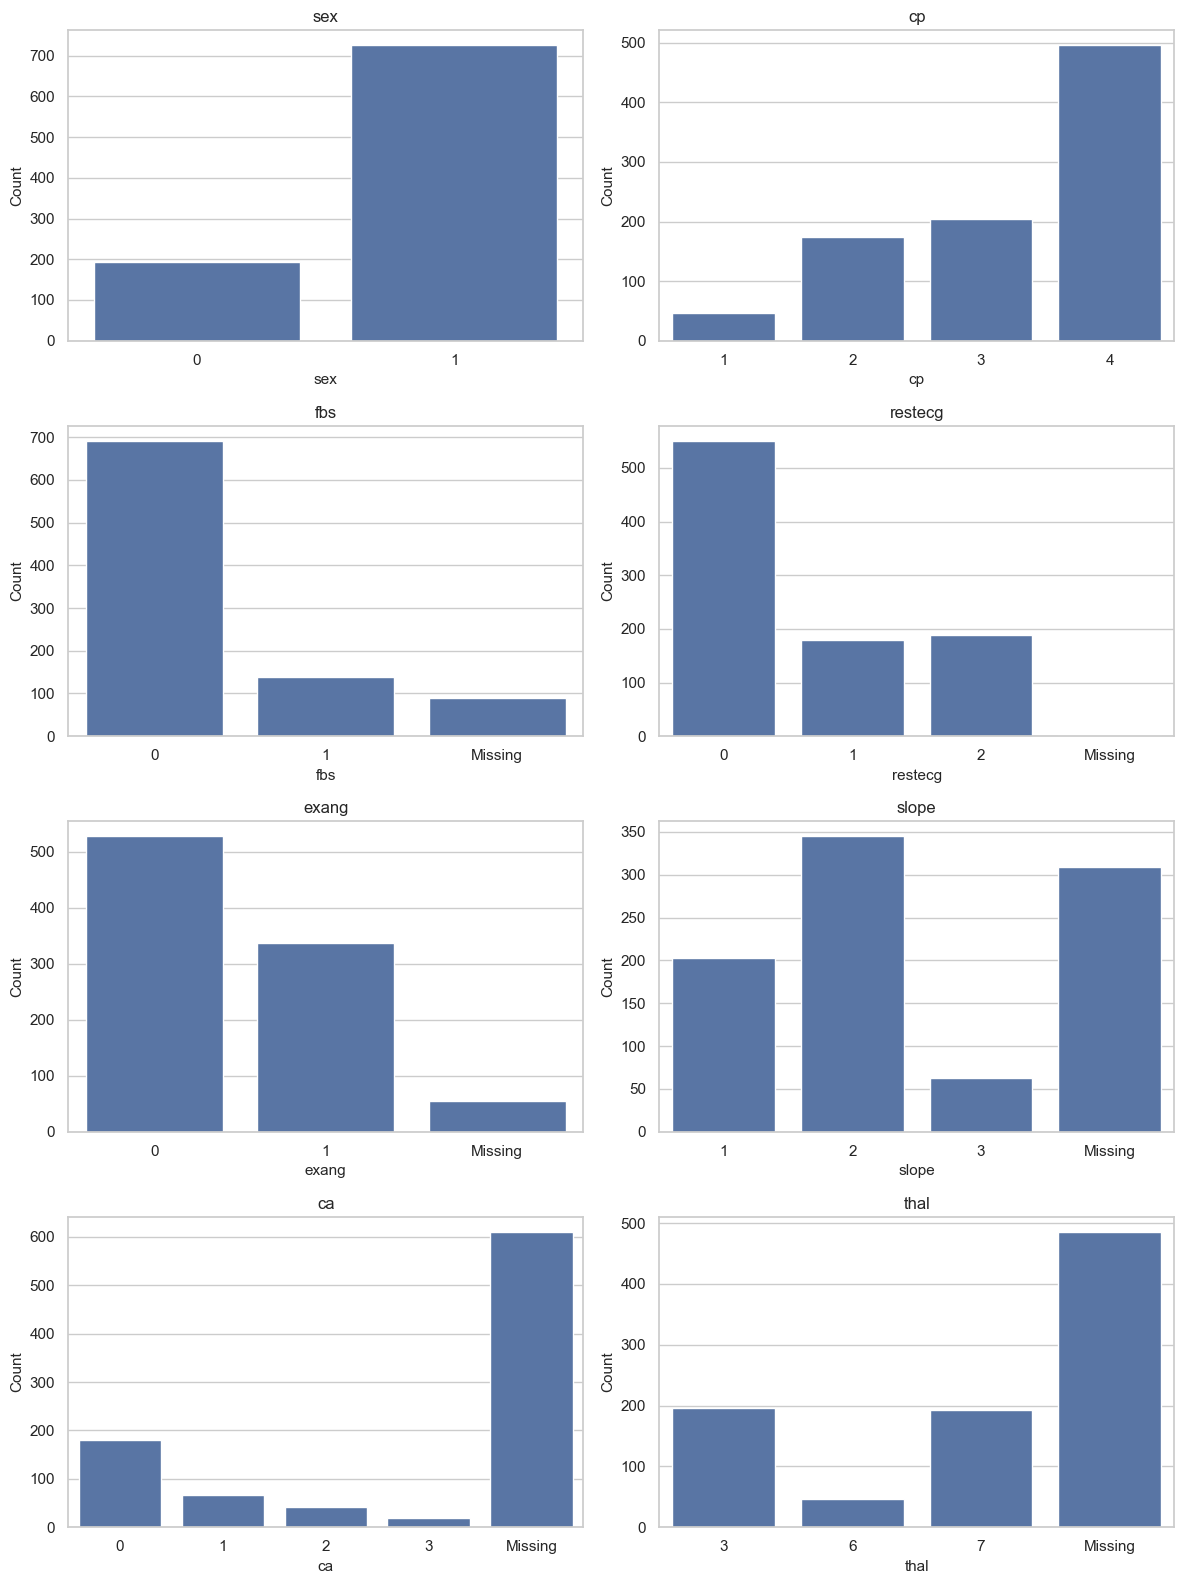

In [9]:
ncols = 2
nrows = int(np.ceil(len(categorical_features) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, categorical_features):
    counts = df[col].astype("Int64").astype(str).replace("<NA>", "Missing").value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values, ax=ax)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

for ax in axes[len(categorical_features):]:
    ax.set_visible(False)

plt.tight_layout()


## 6. Premiers liens entre covariables et cible

L'objectif n'est pas encore de conclure causalement, mais d'identifier des variables potentiellement discriminantes pour la suite de la modélisation.


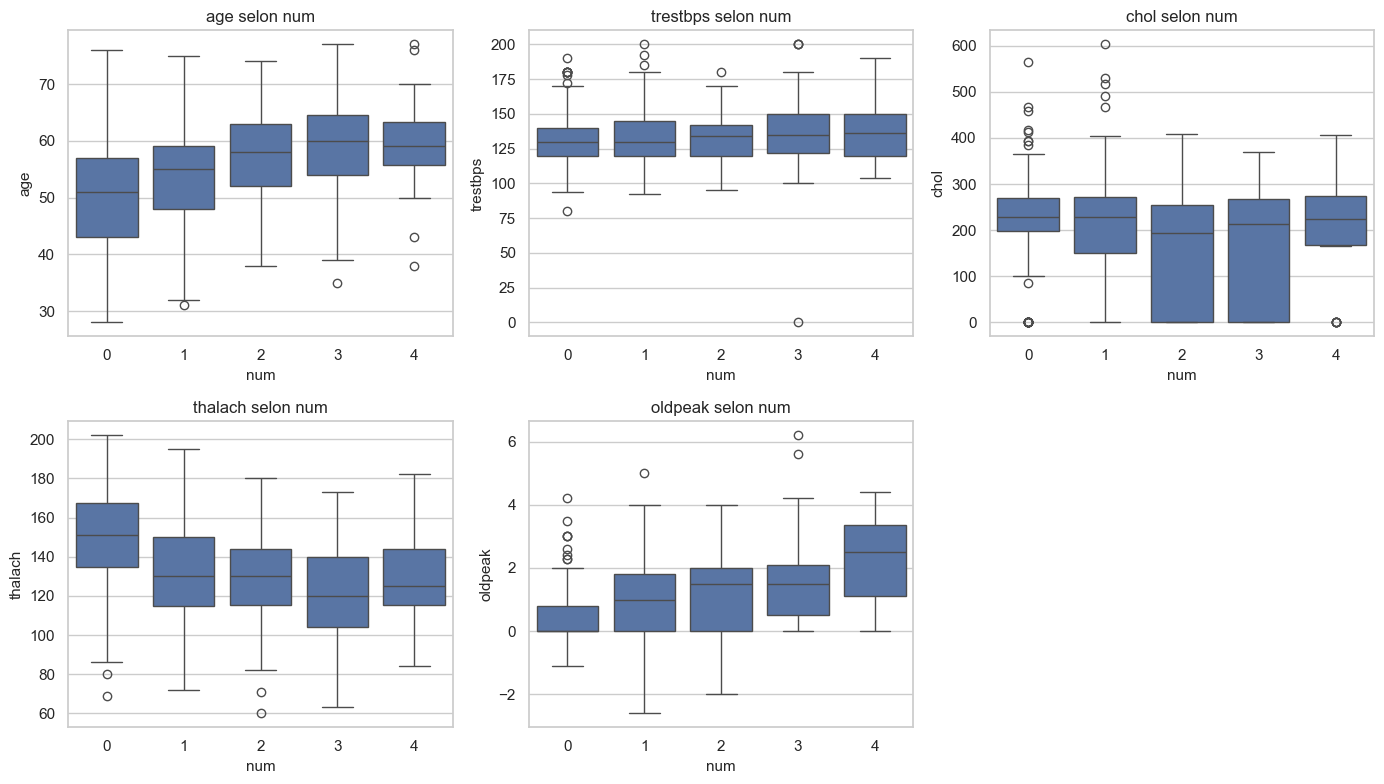

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax, col in zip(axes, quantitative_features):
    sns.boxplot(data=df, x="num", y=col, ax=ax)
    ax.set_title(f"{col} selon num")

for ax in axes[len(quantitative_features):]:
    ax.set_visible(False)

plt.tight_layout()


### Synthèse de l'EDA

Les principaux enseignements de l'analyse exploratoire sont les suivants :

1. la fusion des quatre bases est faisable et informative ;
2. la cible multiclasse existe réellement, mais elle reste plus difficile à prédire que la cible binaire ;
3. trois variables (`ca`, `thal`, `slope`) sont potentiellement utiles mais fortement incomplètes ;
4. le **complete-case analysis** serait très coûteux : seules **299 observations**, soit environ **32.5 %** du dataset, sont complètes sur l'ensemble des variables.

Compte tenu de ces constats, la suite du travail repose sur un protocole rigoureux en deux temps :
- une **séparation train/test explicite**, réalisée avant toute opération apprise sur les données ;
- une **validation croisée stratifiée sur le seul jeu d'entraînement** afin de comparer proprement les stratégies d'imputation et les modèles, sans fuite d'information.


## 7. Méthodologie de modélisation

### Variables retenues

Nous utilisons les 13 variables explicatives standard du dataset. La variable `source` est conservée pour le diagnostic, mais **elle n'est pas incluse dans les modèles principaux**, afin d'éviter qu'un algorithme n'exploite artificiellement les différences entre hôpitaux.

### Stratégies d'imputation comparées

Nous comparons cinq scénarios :

1. **complete_case** : on conserve uniquement les lignes complètes ;
2. **mean_mode** : moyenne pour les variables quantitatives, modalité la plus fréquente pour les variables catégorielles ;
3. **median_mode** : médiane pour les variables quantitatives, modalité la plus fréquente pour les variables catégorielles ;
4. **knn_mode** : KNN imputer sur les variables quantitatives, modalité la plus fréquente pour les variables catégorielles ;
5. **iterative_mode** : imputation itérative pour les variables quantitatives, modalité la plus fréquente pour les variables catégorielles.

### Modèles comparés

Quatre modèles sont évalués :
- régression logistique ;
- random forest ;
- gradient boosting ;
- k plus proches voisins (KNN).

### Protocole de validation retenu

Le protocole suit désormais les étapes suivantes :

1. **séparation train/test explicite** avec `train_test_split`, en utilisant `stratify=y` pour conserver la structure de la cible dans les deux sous-échantillons ;
2. **construction de pipelines sklearn complets**, dans lesquels l'imputation, le standardisation et l'encodage sont intégrés avant le modèle ;
3. **validation croisée stratifiée à 5 folds sur le seul jeu d'entraînement** pour comparer les scénarios ;
4. **réentraînement du pipeline complet sur tout le train**, puis évaluation finale sur le **jeu de test tenu à l'écart**.

Cette organisation est essentielle pour éviter tout **data leakage** :
- les paramètres d'imputation sont appris uniquement sur les folds d'entraînement ou sur le train complet ;
- le scaling et l'encodage sont eux aussi ajustés uniquement sur les données d'entraînement ;
- le jeu de test n'intervient qu'à la toute fin, pour obtenir une estimation finale plus honnête de la performance.

### Métriques retenues

Pour la cible binaire, nous reportons :
- accuracy ;
- precision ;
- recall ;
- F1-score ;
- ROC-AUC.

Pour la cible multiclasse, nous reportons les versions **macro** de precision, recall et F1, ainsi qu'une **ROC-AUC one-vs-rest macro**.


In [11]:

features = ["age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach", "exang", "oldpeak", "slope", "ca", "thal"]
target_binary = (df["num"] > 0).astype(int)
target_multiclass = df["num"].astype(int)

num_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
cat_features = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

def make_preprocessor(strategy):
    onehot = OneHotEncoder(handle_unknown="ignore")

    if strategy == "complete_case":
        num_pipe = Pipeline([
            ("scaler", StandardScaler())
        ])
        cat_pipe = Pipeline([
            ("onehot", onehot)
        ])
    elif strategy == "mean_mode":
        num_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler())
        ])
        cat_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", onehot)
        ])
    elif strategy == "median_mode":
        num_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
        cat_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", onehot)
        ])
    elif strategy == "knn_mode":
        num_pipe = Pipeline([
            ("imputer", KNNImputer(n_neighbors=5)),
            ("scaler", StandardScaler())
        ])
        cat_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", onehot)
        ])
    elif strategy == "iterative_mode":
        num_pipe = Pipeline([
            ("imputer", IterativeImputer(random_state=RANDOM_STATE, max_iter=10)),
            ("scaler", StandardScaler())
        ])
        cat_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", onehot)
        ])
    else:
        raise ValueError(f"Strategie inconnue : {strategy}")

    return ColumnTransformer([
        ("num", num_pipe, num_features),
        ("cat", cat_pipe, cat_features),
    ])


models = {
    "Logistic Regression": LogisticRegression(max_iter=4000, solver="lbfgs"),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=9),
}


def get_scoring(task_name):
    if task_name == "binary":
        return {
            "accuracy": "accuracy",
            "precision": "precision",
            "recall": "recall",
            "f1": "f1",
            "roc_auc": "roc_auc",
        }
    return {
        "accuracy": "accuracy",
        "precision": "precision_macro",
        "recall": "recall_macro",
        "f1": "f1_macro",
        "roc_auc": "roc_auc_ovr",
    }


def evaluate_task(df_input, y, task_name):
    """
    Évalue chaque couple (imputation, modèle) sans fuite d'information :
    1. split train/test explicite ;
    2. validation croisée uniquement sur le train ;
    3. fit final sur tout le train ;
    4. évaluation finale sur le test tenu à l'écart.
    """
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    strategies = ["complete_case", "mean_mode", "median_mode", "knn_mode", "iterative_mode"]

    result_rows = []
    artifacts = {}

    for strategy in strategies:
        if strategy == "complete_case":
            # Cette étape ne constitue pas une fuite d'information :
            # on restreint simplement la population étudiée aux lignes complètes.
            mask = df_input[features].notna().all(axis=1)
            X_all = df_input.loc[mask, features].copy()
            y_all = y.loc[mask].copy()
            source_all = df_input.loc[mask, "source"].copy()
        else:
            X_all = df_input[features].copy()
            y_all = y.copy()
            source_all = df_input["source"].copy()

        X_train, X_test, y_train, y_test, source_train, source_test = train_test_split(
            X_all,
            y_all,
            source_all,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
            stratify=y_all,
        )

        for model_name, model in models.items():
            pipe = Pipeline([
                ("preprocessor", make_preprocessor(strategy)),
                ("model", model),
            ])

            cv_scores = cross_validate(
                pipe,
                X_train,
                y_train,
                cv=cv,
                scoring=get_scoring(task_name),
                n_jobs=None,
                return_train_score=False,
            )

            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)
            y_proba = pipe.predict_proba(X_test)

            row = {
                "task": task_name,
                "imputation": strategy,
                "model": model_name,
                "n_train": len(X_train),
                "n_test": len(X_test),
            }

            for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
                row[f"cv_{metric}_mean"] = float(np.mean(cv_scores[f"test_{metric}"]))
                row[f"cv_{metric}_std"] = float(np.std(cv_scores[f"test_{metric}"]))

            row["test_accuracy"] = accuracy_score(y_test, y_pred)

            if task_name == "binary":
                row["test_precision"] = precision_score(y_test, y_pred, zero_division=0)
                row["test_recall"] = recall_score(y_test, y_pred, zero_division=0)
                row["test_f1"] = f1_score(y_test, y_pred, zero_division=0)
                row["test_roc_auc"] = roc_auc_score(y_test, y_proba[:, 1])
            else:
                row["test_precision"] = precision_score(y_test, y_pred, average="macro", zero_division=0)
                row["test_recall"] = recall_score(y_test, y_pred, average="macro", zero_division=0)
                row["test_f1"] = f1_score(y_test, y_pred, average="macro", zero_division=0)
                row["test_roc_auc"] = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")

            result_rows.append(row)
            artifacts[(task_name, strategy, model_name)] = {
                "pipeline": pipe,
                "X_train": X_train.copy(),
                "X_test": X_test.copy(),
                "y_train": np.array(y_train),
                "y_test": np.array(y_test),
                "y_pred": np.array(y_pred),
                "y_proba": np.array(y_proba),
                "source_test": np.array(source_test),
            }

    results = pd.DataFrame(result_rows)
    return results, artifacts


## 8. Comparaison des scénarios sur train puis test

La cellule suivante peut être relativement longue à exécuter, car elle entraîne l'ensemble des combinaisons **imputation × modèle × type de cible**.

Lecture méthodologique :
- les colonnes `cv_*` résument la validation croisée réalisée **uniquement sur le train** ;
- les colonnes `test_*` correspondent à l'évaluation finale sur le **jeu de test tenu à l'écart** ;
- ce double niveau de lecture permet de comparer les scénarios sans fuite d'information, puis de vérifier leur comportement final sur des observations jamais utilisées durant la sélection.


In [12]:

binary_results, binary_artifacts = evaluate_task(df, target_binary, task_name="binary")
multiclass_results, multiclass_artifacts = evaluate_task(df, target_multiclass, task_name="multiclass")

binary_cols = [
    "imputation", "model", "n_train", "n_test",
    "cv_accuracy_mean", "cv_precision_mean", "cv_recall_mean", "cv_f1_mean", "cv_roc_auc_mean",
    "test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"
]

multiclass_cols = [
    "imputation", "model", "n_train", "n_test",
    "cv_accuracy_mean", "cv_precision_mean", "cv_recall_mean", "cv_f1_mean", "cv_roc_auc_mean",
    "test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"
]

print("Résultats binaires")
display(binary_results[binary_cols].sort_values(["cv_roc_auc_mean", "test_roc_auc"], ascending=False).round(3))

print("Résultats multiclasses")
display(multiclass_results[multiclass_cols].sort_values(["cv_roc_auc_mean", "test_roc_auc"], ascending=False).round(3))


Résultats binaires


,imputation,model,n_train,n_test,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,complete_case,Logistic Regression,239,60,0.862,0.879,0.819,0.846,0.922,0.817,0.870,0.714,0.784,0.913
1,complete_case,Random Forest,239,60,0.812,0.815,0.783,0.793,0.915,0.817,0.840,0.750,0.792,0.920
2,complete_case,Gradient Boosting,239,60,0.799,0.803,0.756,0.777,0.897,0.783,0.857,0.643,0.735,0.850
3,complete_case,KNN,239,60,0.808,0.827,0.747,0.783,0.890,0.850,0.852,0.821,0.836,0.937
8,median_mode,Logistic Regression,736,184,0.810,0.823,0.843,0.831,0.885,0.842,0.848,0.873,0.860,0.909
4,mean_mode,Logistic Regression,736,184,0.807,0.821,0.840,0.829,0.885,0.842,0.848,0.873,0.860,0.910
16,iterative_mode,Logistic Regression,736,184,0.811,0.822,0.848,0.833,0.884,0.837,0.840,0.873,0.856,0.911
17,iterative_mode,Random Forest,736,184,0.806,0.813,0.850,0.830,0.884,0.870,0.861,0.912,0.886,0.926
12,knn_mode,Logistic Regression,736,184,0.800,0.814,0.835,0.823,0.883,0.837,0.840,0.873,0.856,0.911
11,median_mode,KNN,736,184,0.825,0.832,0.862,0.846,0.882,0.842,0.854,0.863,0.859,0.902


Résultats multiclasses


,imputation,model,n_train,n_test,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean,cv_roc_auc_mean,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
1,complete_case,Random Forest,239,60,0.577,0.356,0.299,0.297,0.795,0.583,0.231,0.265,0.244,0.809
16,iterative_mode,Logistic Regression,736,184,0.564,0.336,0.347,0.338,0.791,0.571,0.348,0.349,0.343,0.795
4,mean_mode,Logistic Regression,736,184,0.568,0.340,0.349,0.340,0.791,0.565,0.332,0.341,0.332,0.793
8,median_mode,Logistic Regression,736,184,0.564,0.338,0.345,0.337,0.790,0.560,0.325,0.337,0.328,0.792
12,knn_mode,Logistic Regression,736,184,0.567,0.341,0.350,0.342,0.788,0.571,0.335,0.344,0.333,0.796
17,iterative_mode,Random Forest,736,184,0.578,0.358,0.354,0.348,0.767,0.582,0.288,0.317,0.300,0.815
13,knn_mode,Random Forest,736,184,0.568,0.360,0.347,0.345,0.764,0.592,0.326,0.349,0.336,0.803
9,median_mode,Random Forest,736,184,0.563,0.355,0.347,0.343,0.764,0.582,0.320,0.337,0.326,0.803
18,iterative_mode,Gradient Boosting,736,184,0.573,0.367,0.359,0.357,0.757,0.582,0.353,0.355,0.352,0.783
5,mean_mode,Random Forest,736,184,0.564,0.353,0.344,0.339,0.755,0.571,0.317,0.338,0.326,0.808


In [13]:

binary_rank = binary_results.sort_values(
    ["cv_roc_auc_mean", "cv_recall_mean", "test_roc_auc", "test_recall"],
    ascending=False
).reset_index(drop=True)

binary_rank_imputed = binary_results.query("imputation != 'complete_case'").sort_values(
    ["cv_roc_auc_mean", "cv_recall_mean", "test_roc_auc", "test_recall"],
    ascending=False
).reset_index(drop=True)

multiclass_rank = multiclass_results.sort_values(
    ["cv_roc_auc_mean", "cv_f1_mean", "test_roc_auc"],
    ascending=False
).reset_index(drop=True)

print("Classement binaire (tous scénarios)")
display(binary_rank.round(3))

print("Classement binaire (hors complete-case, pour retenir un scénario exploitable sur 920 patients)")
display(binary_rank_imputed.round(3))

print("Classement multiclasse")
display(multiclass_rank.round(3))


Classement binaire (tous scénarios)


,task,imputation,model,n_train,n_test,cv_accuracy_mean,cv_accuracy_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,binary,complete_case,Logistic Regression,239,60,0.862,0.032,0.879,0.053,0.819,0.059,0.846,0.036,0.922,0.026,0.817,0.870,0.714,0.784,0.913
1,binary,complete_case,Random Forest,239,60,0.812,0.045,0.815,0.077,0.783,0.089,0.793,0.050,0.915,0.013,0.817,0.840,0.750,0.792,0.920
2,binary,complete_case,Gradient Boosting,239,60,0.799,0.023,0.803,0.033,0.756,0.063,0.777,0.032,0.897,0.015,0.783,0.857,0.643,0.735,0.850
3,binary,complete_case,KNN,239,60,0.808,0.044,0.827,0.072,0.747,0.049,0.783,0.048,0.890,0.036,0.850,0.852,0.821,0.836,0.937
4,binary,median_mode,Logistic Regression,736,184,0.810,0.033,0.823,0.052,0.843,0.030,0.831,0.024,0.885,0.022,0.842,0.848,0.873,0.860,0.909
5,binary,mean_mode,Logistic Regression,736,184,0.807,0.031,0.821,0.049,0.840,0.031,0.829,0.022,0.885,0.022,0.842,0.848,0.873,0.860,0.910
6,binary,iterative_mode,Logistic Regression,736,184,0.811,0.031,0.822,0.049,0.848,0.033,0.833,0.022,0.884,0.023,0.837,0.840,0.873,0.856,0.911
7,binary,iterative_mode,Random Forest,736,184,0.806,0.037,0.813,0.054,0.850,0.018,0.830,0.026,0.884,0.024,0.870,0.861,0.912,0.886,0.926
8,binary,knn_mode,Logistic Regression,736,184,0.800,0.030,0.814,0.049,0.835,0.038,0.823,0.022,0.883,0.021,0.837,0.840,0.873,0.856,0.911
9,binary,median_mode,KNN,736,184,0.825,0.028,0.832,0.049,0.862,0.019,0.846,0.019,0.882,0.024,0.842,0.854,0.863,0.859,0.902


Classement binaire (hors complete-case, pour retenir un scénario exploitable sur 920 patients)


,task,imputation,model,n_train,n_test,cv_accuracy_mean,cv_accuracy_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,binary,median_mode,Logistic Regression,736,184,0.810,0.033,0.823,0.052,0.843,0.030,0.831,0.024,0.885,0.022,0.842,0.848,0.873,0.860,0.909
1,binary,mean_mode,Logistic Regression,736,184,0.807,0.031,0.821,0.049,0.840,0.031,0.829,0.022,0.885,0.022,0.842,0.848,0.873,0.860,0.910
2,binary,iterative_mode,Logistic Regression,736,184,0.811,0.031,0.822,0.049,0.848,0.033,0.833,0.022,0.884,0.023,0.837,0.840,0.873,0.856,0.911
3,binary,iterative_mode,Random Forest,736,184,0.806,0.037,0.813,0.054,0.850,0.018,0.830,0.026,0.884,0.024,0.870,0.861,0.912,0.886,0.926
4,binary,knn_mode,Logistic Regression,736,184,0.800,0.030,0.814,0.049,0.835,0.038,0.823,0.022,0.883,0.021,0.837,0.840,0.873,0.856,0.911
5,binary,median_mode,KNN,736,184,0.825,0.028,0.832,0.049,0.862,0.019,0.846,0.019,0.882,0.024,0.842,0.854,0.863,0.859,0.902
6,binary,median_mode,Random Forest,736,184,0.806,0.033,0.815,0.053,0.848,0.022,0.829,0.021,0.881,0.025,0.859,0.852,0.902,0.876,0.927
7,binary,mean_mode,Random Forest,736,184,0.806,0.034,0.817,0.056,0.845,0.024,0.829,0.022,0.881,0.025,0.864,0.853,0.912,0.882,0.928
8,binary,knn_mode,Random Forest,736,184,0.808,0.029,0.819,0.054,0.848,0.027,0.831,0.019,0.881,0.025,0.859,0.852,0.902,0.876,0.926
9,binary,mean_mode,KNN,736,184,0.821,0.041,0.826,0.056,0.862,0.014,0.843,0.030,0.879,0.027,0.842,0.854,0.863,0.859,0.904


Classement multiclasse


,task,imputation,model,n_train,n_test,cv_accuracy_mean,cv_accuracy_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,multiclass,complete_case,Random Forest,239,60,0.577,0.023,0.356,0.080,0.299,0.020,0.297,0.035,0.795,0.013,0.583,0.231,0.265,0.244,0.809
1,multiclass,iterative_mode,Logistic Regression,736,184,0.564,0.038,0.336,0.038,0.347,0.037,0.338,0.037,0.791,0.024,0.571,0.348,0.349,0.343,0.795
2,multiclass,mean_mode,Logistic Regression,736,184,0.568,0.042,0.340,0.041,0.349,0.038,0.340,0.039,0.791,0.025,0.565,0.332,0.341,0.332,0.793
3,multiclass,median_mode,Logistic Regression,736,184,0.564,0.040,0.338,0.041,0.345,0.038,0.337,0.038,0.790,0.025,0.560,0.325,0.337,0.328,0.792
4,multiclass,knn_mode,Logistic Regression,736,184,0.567,0.039,0.341,0.039,0.350,0.035,0.342,0.036,0.788,0.025,0.571,0.335,0.344,0.333,0.796
5,multiclass,iterative_mode,Random Forest,736,184,0.578,0.036,0.358,0.042,0.354,0.032,0.348,0.033,0.767,0.050,0.582,0.288,0.317,0.300,0.815
6,multiclass,knn_mode,Random Forest,736,184,0.568,0.042,0.360,0.041,0.347,0.029,0.345,0.032,0.764,0.053,0.592,0.326,0.349,0.336,0.803
7,multiclass,median_mode,Random Forest,736,184,0.563,0.042,0.355,0.049,0.347,0.033,0.343,0.035,0.764,0.046,0.582,0.320,0.337,0.326,0.803
8,multiclass,iterative_mode,Gradient Boosting,736,184,0.573,0.024,0.367,0.035,0.359,0.024,0.357,0.026,0.757,0.021,0.582,0.353,0.355,0.352,0.783
9,multiclass,mean_mode,Random Forest,736,184,0.564,0.042,0.353,0.044,0.344,0.030,0.339,0.032,0.755,0.051,0.571,0.317,0.338,0.326,0.808


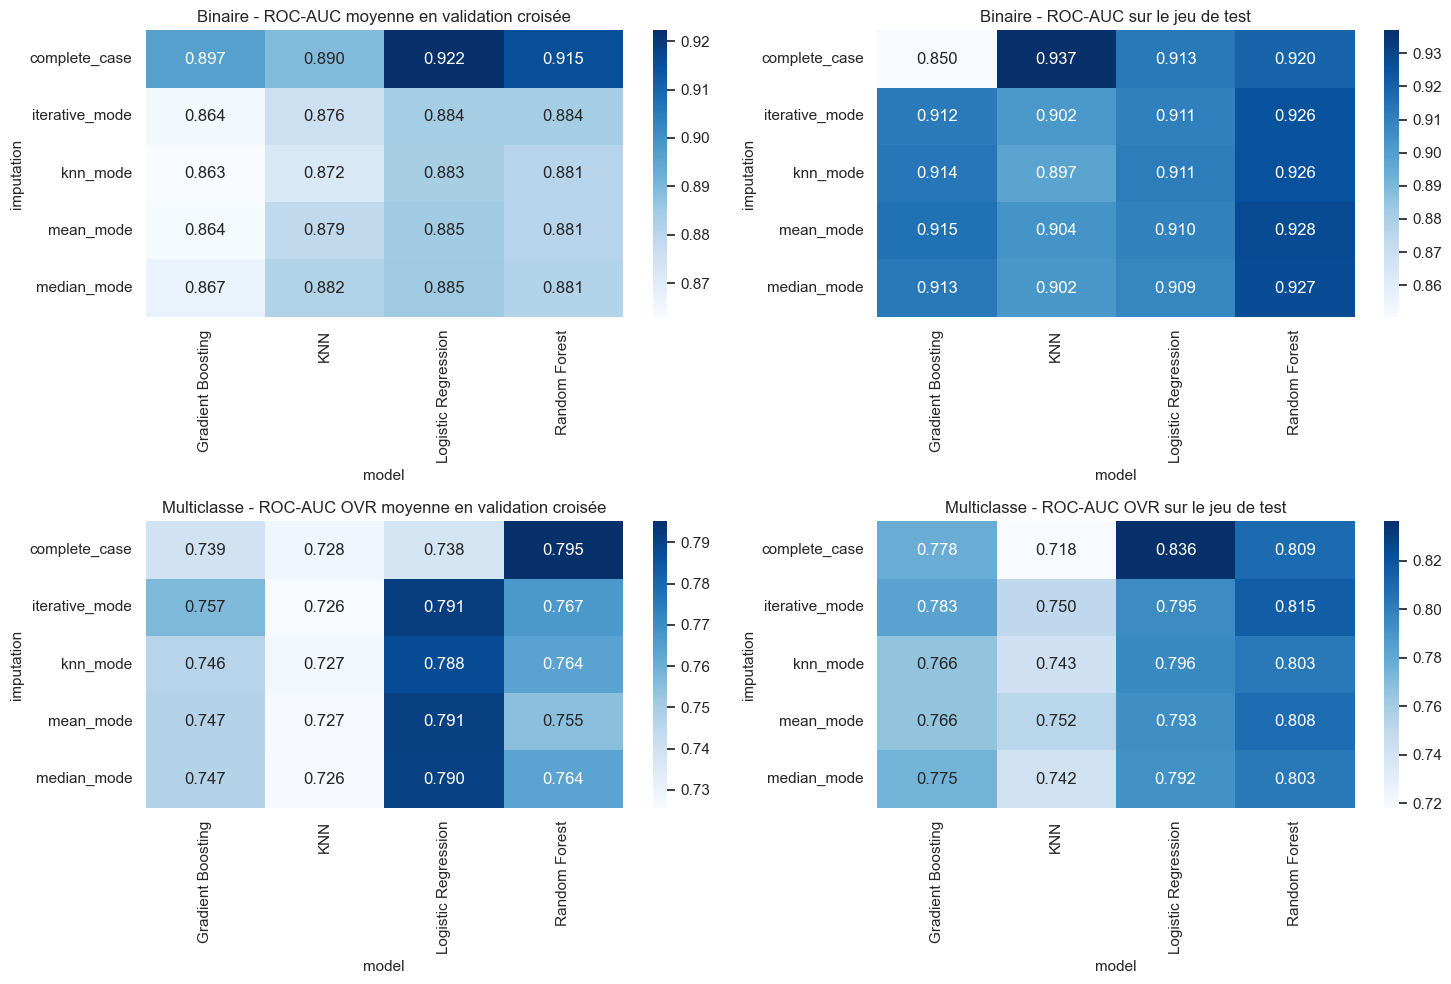

In [14]:

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.heatmap(
    binary_results.pivot(index="imputation", columns="model", values="cv_roc_auc_mean"),
    annot=True, fmt=".3f", cmap="Blues", ax=axes[0, 0]
)
axes[0, 0].set_title("Binaire - ROC-AUC moyenne en validation croisée")

sns.heatmap(
    binary_results.pivot(index="imputation", columns="model", values="test_roc_auc"),
    annot=True, fmt=".3f", cmap="Blues", ax=axes[0, 1]
)
axes[0, 1].set_title("Binaire - ROC-AUC sur le jeu de test")

sns.heatmap(
    multiclass_results.pivot(index="imputation", columns="model", values="cv_roc_auc_mean"),
    annot=True, fmt=".3f", cmap="Blues", ax=axes[1, 0]
)
axes[1, 0].set_title("Multiclasse - ROC-AUC OVR moyenne en validation croisée")

sns.heatmap(
    multiclass_results.pivot(index="imputation", columns="model", values="test_roc_auc"),
    annot=True, fmt=".3f", cmap="Blues", ax=axes[1, 1]
)
axes[1, 1].set_title("Multiclasse - ROC-AUC OVR sur le jeu de test")

plt.tight_layout()


## 9. Ajustement du seuil de décision pour privilégier le recall

Dans le cadre de cette étude, un **faux négatif** (patient à risque classé à tort comme non malade) est généralement plus problématique qu'un **faux positif**.  
Il est donc pertinent d'étudier le **seuil de décision** du meilleur modèle binaire retenu.

Important :
- la **ROC-AUC** ne dépend pas d'un seuil particulier ; elle mesure la capacité globale de classement ;
- en revanche, **precision**, **recall**, **F1**, ainsi que le nombre de **FP / FN**, dépendent directement du seuil retenu ;
- l'objectif ici est donc de rechercher un seuil donnant un **rappel élevé**, tout en conservant un niveau de précision encore acceptable.


Meilleur score binaire absolu


,task,imputation,model,n_train,n_test,cv_accuracy_mean,cv_accuracy_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,binary,complete_case,Logistic Regression,239,60,0.862,0.032,0.879,0.053,0.819,0.059,0.846,0.036,0.922,0.026,0.817,0.870,0.714,0.784,0.913


Modèle binaire retenu pour la suite (hors complete-case)


,task,imputation,model,n_train,n_test,cv_accuracy_mean,cv_accuracy_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,binary,median_mode,Logistic Regression,736,184,0.810,0.033,0.823,0.052,0.843,0.030,0.831,0.024,0.885,0.022,0.842,0.848,0.873,0.860,0.909


Meilleur modèle multiclasse


,task,imputation,model,n_train,n_test,cv_accuracy_mean,cv_accuracy_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,multiclass,complete_case,Random Forest,239,60,0.577,0.023,0.356,0.080,0.299,0.020,0.297,0.035,0.795,0.013,0.583,0.231,0.265,0.244,0.809


,threshold,accuracy,precision,recall,f1,fp,fn,tp,tn
0,0.200,0.788,0.727,0.990,0.838,38,1,101,44
1,0.250,0.788,0.740,0.951,0.833,34,5,97,48
2,0.300,0.810,0.768,0.941,0.846,29,6,96,53
3,0.350,0.815,0.788,0.912,0.845,25,9,93,57
4,0.400,0.826,0.807,0.902,0.852,22,10,92,60
5,0.450,0.821,0.811,0.882,0.845,21,12,90,61
6,0.500,0.842,0.848,0.873,0.860,16,13,89,66
7,0.550,0.837,0.846,0.863,0.854,16,14,88,66
8,0.600,0.821,0.848,0.824,0.836,15,18,84,67
9,0.650,0.821,0.856,0.814,0.834,14,19,83,68


Seuil retenu : 0.40
Ce seuil est choisi en donnant la priorité au recall, tout en maintenant une précision minimale proche du niveau obtenu au seuil 0.50.


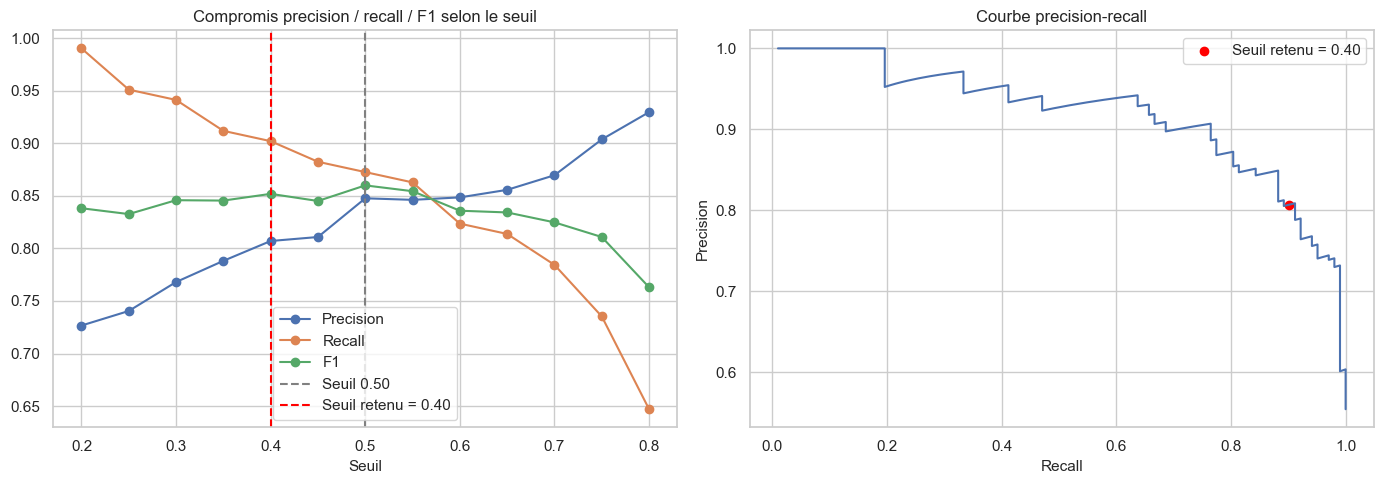

In [15]:

# On distingue ici :
# - le meilleur score binaire absolu ;
# - le scénario binaire retenu pour l'analyse finale, en excluant complete_case
#   afin de rester sur un modèle utilisable sur l'ensemble des 920 patients.

best_binary_absolute = binary_rank.iloc[0]
retained_binary = binary_rank_imputed.iloc[0]
best_multiclass = multiclass_rank.iloc[0]

print("Meilleur score binaire absolu")
display(pd.DataFrame([best_binary_absolute]).round(3))

print("Modèle binaire retenu pour la suite (hors complete-case)")
display(pd.DataFrame([retained_binary]).round(3))

print("Meilleur modèle multiclasse")
display(pd.DataFrame([best_multiclass]).round(3))

retained_binary_artifact = binary_artifacts[(
    "binary",
    retained_binary["imputation"],
    retained_binary["model"],
)]

y_true_bin = retained_binary_artifact["y_test"]
y_score_bin = retained_binary_artifact["y_proba"][:, 1]
y_pred_bin_default = (y_score_bin >= 0.50).astype(int)

threshold_grid = np.arange(0.20, 0.81, 0.05)
threshold_rows = []

for thr in threshold_grid:
    y_pred_thr = (y_score_bin >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_thr).ravel()

    threshold_rows.append({
        "threshold": thr,
        "accuracy": accuracy_score(y_true_bin, y_pred_thr),
        "precision": precision_score(y_true_bin, y_pred_thr, zero_division=0),
        "recall": recall_score(y_true_bin, y_pred_thr, zero_division=0),
        "f1": f1_score(y_true_bin, y_pred_thr, zero_division=0),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "tn": int(tn),
    })

threshold_results = pd.DataFrame(threshold_rows)

default_row = threshold_results.loc[np.isclose(threshold_results["threshold"], 0.50)].iloc[0]
precision_floor = max(0.60, default_row["precision"] - 0.05)

eligible_thresholds = threshold_results.query("precision >= @precision_floor").copy()

if len(eligible_thresholds) == 0:
    threshold_choice = threshold_results.sort_values(
        ["recall", "f1", "precision"],
        ascending=False
    ).iloc[0]
else:
    threshold_choice = eligible_thresholds.sort_values(
        ["recall", "f1", "precision"],
        ascending=False
    ).iloc[0]

final_threshold = float(threshold_choice["threshold"])
y_pred_bin_adjusted = (y_score_bin >= final_threshold).astype(int)

display(threshold_results.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(threshold_results["threshold"], threshold_results["precision"], marker="o", label="Precision")
axes[0].plot(threshold_results["threshold"], threshold_results["recall"], marker="o", label="Recall")
axes[0].plot(threshold_results["threshold"], threshold_results["f1"], marker="o", label="F1")
axes[0].axvline(0.50, linestyle="--", color="grey", label="Seuil 0.50")
axes[0].axvline(final_threshold, linestyle="--", color="red", label=f"Seuil retenu = {final_threshold:.2f}")
axes[0].set_title("Compromis precision / recall / F1 selon le seuil")
axes[0].set_xlabel("Seuil")
axes[0].legend()

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_true_bin, y_score_bin)
axes[1].plot(recall_curve[:-1], precision_curve[:-1])
axes[1].scatter(
    threshold_choice["recall"],
    threshold_choice["precision"],
    color="red",
    label=f"Seuil retenu = {final_threshold:.2f}"
)
axes[1].set_title("Courbe precision-recall")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()

print(f"Seuil retenu : {final_threshold:.2f}")
print(
    "Ce seuil est choisi en donnant la priorité au recall, "
    "tout en maintenant une précision minimale proche du niveau obtenu au seuil 0.50."
)


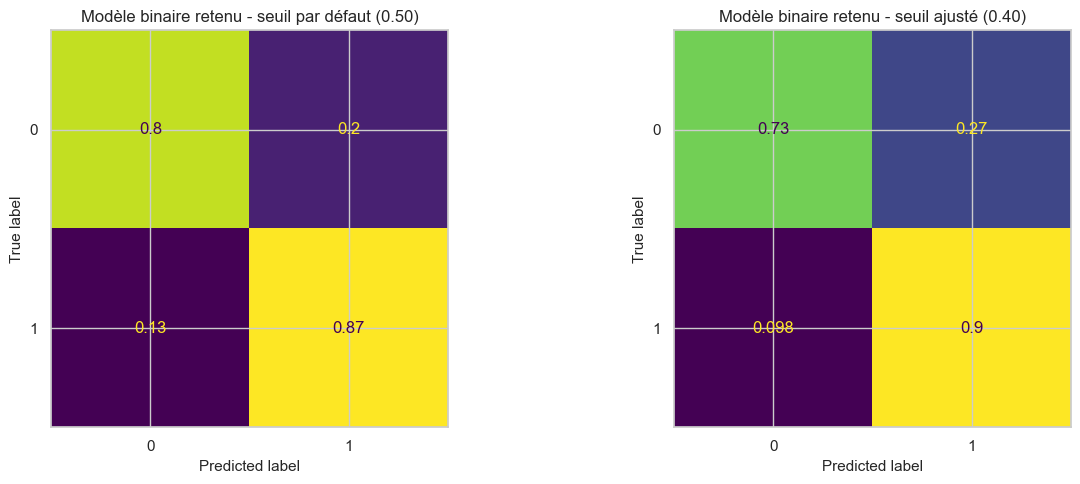

In [16]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_true_bin,
    y_pred_bin_default,
    normalize="true",
    colorbar=False,
    ax=axes[0]
)
axes[0].set_title("Modèle binaire retenu - seuil par défaut (0.50)")

ConfusionMatrixDisplay.from_predictions(
    y_true_bin,
    y_pred_bin_adjusted,
    normalize="true",
    colorbar=False,
    ax=axes[1]
)
axes[1].set_title(f"Modèle binaire retenu - seuil ajusté ({final_threshold:.2f})")

plt.tight_layout()


## 10. Lecture des résultats

La comparaison doit désormais être lue en deux temps :

1. **validation croisée sur le train** : elle sert à comparer les scénarios de manière stable, sans utiliser le test pour sélectionner un modèle ;
2. **évaluation sur le test** : elle permet de vérifier qu'un bon scénario en validation croisée reste crédible sur des observations totalement tenues à l'écart.

Il est normal que les valeurs `cv_*` et `test_*` ne soient pas exactement identiques.  
En revanche, un scénario réellement robuste ne doit pas changer complètement de hiérarchie entre ces deux niveaux de lecture.


### Commentaire interprétatif mis à jour

Plusieurs points doivent être examinés avec attention lors de la lecture du tableau :

- si le **complete-case** obtient les meilleurs scores absolus, cela ne signifie pas automatiquement qu'il s'agit du meilleur scénario opérationnel : il repose sur une population beaucoup plus réduite et potentiellement différente du jeu complet ;
- le scénario **retenu pour la suite** est donc de préférence recherché parmi les méthodes d'imputation exploitant l'ensemble des **920 patients** ;
- en classification binaire, on attend généralement une hiérarchie plus stable et des performances plus élevées qu'en multiclasse ;
- la cohérence entre `cv_roc_auc_mean` et `test_roc_auc` est un bon signal de robustesse ; à l'inverse, un écart très fort inviterait à davantage de prudence.

Dans la soutenance, il faudra donc distinguer :
1. le **meilleur score absolu** ;
2. le **meilleur compromis méthodologique**, c'est-à-dire un scénario performant, interprétable et exploitable sur l'ensemble de la base.


## 11. Diagnostics détaillés sur les modèles retenus

Nous poursuivons l'analyse avec :
- le **modèle binaire retenu** pour un usage principal, c'est-à-dire le meilleur scénario hors `complete_case` ;
- le **meilleur modèle multiclasse** selon la validation croisée et le test.

Les diagnostics ci-dessous reposent sur le **jeu de test tenu à l'écart**, ce qui permet une lecture plus rigoureuse que des prédictions réinjectées sur le train.


In [17]:

# Récapitulatif des modèles retenus pour les diagnostics finaux
display(pd.DataFrame([retained_binary]).round(3))
display(pd.DataFrame([best_multiclass]).round(3))

multiclass_artifact = multiclass_artifacts[(
    "multiclass",
    best_multiclass["imputation"],
    best_multiclass["model"],
)]


,task,imputation,model,n_train,n_test,cv_accuracy_mean,cv_accuracy_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,binary,median_mode,Logistic Regression,736,184,0.810,0.033,0.823,0.052,0.843,0.030,0.831,0.024,0.885,0.022,0.842,0.848,0.873,0.860,0.909


,task,imputation,model,n_train,n_test,cv_accuracy_mean,cv_accuracy_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,multiclass,complete_case,Random Forest,239,60,0.577,0.023,0.356,0.080,0.299,0.020,0.297,0.035,0.795,0.013,0.583,0.231,0.265,0.244,0.809


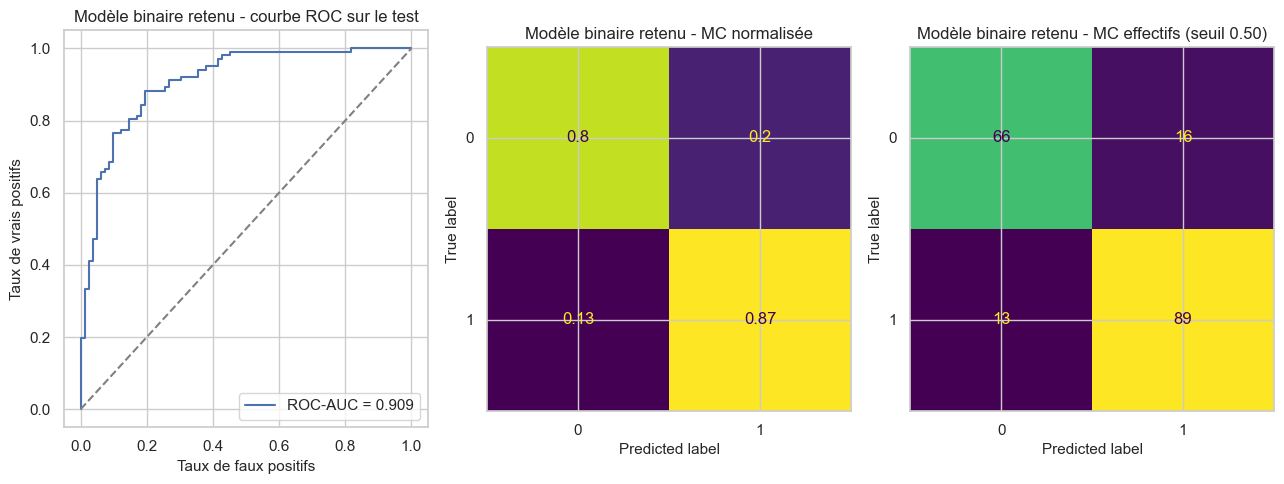

In [37]:

# Diagnostic binaire : courbe ROC + matrice de confusion au seuil par défaut
fpr, tpr, _ = roc_curve(y_true_bin, y_score_bin)
auc_bin = roc_auc_score(y_true_bin, y_score_bin)

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

axes[0].plot(fpr, tpr, label=f"ROC-AUC = {auc_bin:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[0].set_title("Modèle binaire retenu - courbe ROC sur le test")
axes[0].set_xlabel("Taux de faux positifs")
axes[0].set_ylabel("Taux de vrais positifs")
axes[0].legend(loc="lower right")

ConfusionMatrixDisplay.from_predictions(
    y_true_bin, y_pred_bin_default, normalize="true", colorbar=False, ax=axes[1]
)
axes[1].set_title("Modèle binaire retenu - MC normalisée")

ConfusionMatrixDisplay.from_predictions(
    y_true_bin, y_pred_bin_default, normalize=None, colorbar=False, ax=axes[2]
)
axes[2].set_title("Modèle binaire retenu - MC effectifs (seuil 0.50)")

plt.tight_layout()


,class,ovr_auc
0,0,0.968
1,1,0.721
2,2,0.795
3,3,0.765
4,4,0.798


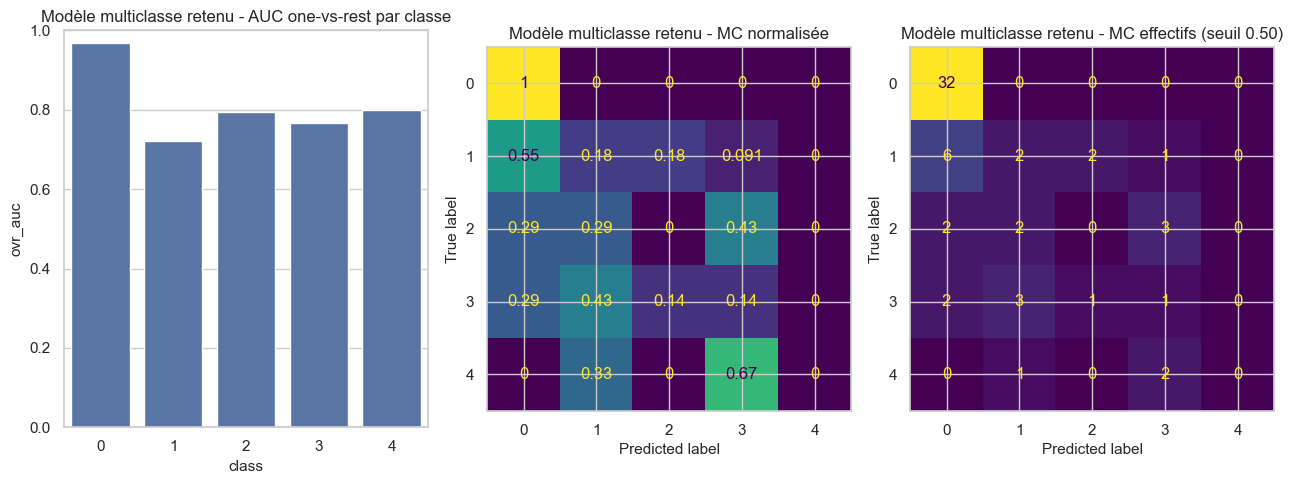

In [39]:

# Diagnostic multiclasse : matrice de confusion + AUC one-vs-rest par classe
y_true_multi = multiclass_artifact["y_test"]
y_pred_multi = multiclass_artifact["y_pred"]
y_proba_multi = multiclass_artifact["y_proba"]

classes = np.unique(y_true_multi)
per_class_auc = []
for i, class_value in enumerate(classes):
    auc = roc_auc_score((y_true_multi == class_value).astype(int), y_proba_multi[:, i])
    per_class_auc.append({"class": int(class_value), "ovr_auc": auc})

per_class_auc = pd.DataFrame(per_class_auc)
display(per_class_auc.round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

sns.barplot(data=per_class_auc, x="class", y="ovr_auc", ax=axes[0])
axes[0].set_ylim(0, 1)
axes[0].set_title("Modèle multiclasse retenu - AUC one-vs-rest par classe")

# Matrice de confusion normalisée
ConfusionMatrixDisplay.from_predictions(
    y_true_multi, y_pred_multi, normalize="true", colorbar=False, ax=axes[1]
)
axes[1].set_title("Modèle multiclasse retenu - MC normalisée")

# Matrice de confusion brute (effectifs)
ConfusionMatrixDisplay.from_predictions(
    y_true_multi, y_pred_multi, normalize=None, colorbar=False, ax=axes[2]
)
axes[2].set_title("Modèle multiclasse retenu - MC effectifs (seuil 0.50)")

plt.tight_layout()


In [40]:

# Diagnostic par source pour le modèle binaire retenu
binary_diag = pd.DataFrame({
    "source": retained_binary_artifact["source_test"],
    "y_true": y_true_bin,
    "y_pred": y_pred_bin_default,
    "y_score": y_score_bin,
})

source_binary_summary = binary_diag.groupby("source").apply(
    lambda g: pd.Series({
        "n_obs": len(g),
        "positive_rate": g["y_true"].mean(),
        "accuracy": accuracy_score(g["y_true"], g["y_pred"]),
        "recall": recall_score(g["y_true"], g["y_pred"], zero_division=0),
        "roc_auc": roc_auc_score(g["y_true"], g["y_score"]) if g["y_true"].nunique() == 2 else np.nan,
    })
).reset_index()

display(source_binary_summary.round(3))


,source,n_obs,positive_rate,accuracy,recall,roc_auc
0,cleveland,55.000,0.473,0.818,0.923,0.950
1,hungarian,64.000,0.344,0.875,0.727,0.909
2,switzerland,28.000,0.964,0.857,0.889,0.185
3,va,37.000,0.730,0.811,0.926,0.763


### Commentaire

Les diagnostics finaux ont trois rôles distincts :

1. **vérifier la discrimination globale** du modèle binaire retenu via la courbe ROC ;
2. **visualiser concrètement les erreurs** à l'aide des matrices de confusion, au seuil par défaut puis au seuil ajusté ;
3. **examiner l'hétérogénéité entre sources**.

Le diagnostic par source ne sert donc pas à améliorer directement le modèle ; il permet surtout de répondre à la question suivante :

> le modèle se comporte-t-il de manière comparable selon l'hôpital d'origine des patients ?

Cette étape est utile car la base finale résulte d'une **fusion de sources hétérogènes**.  
Si les performances diffèrent fortement selon `source`, cela peut signaler :
- des profils de patients différents ;
- une qualité de mesure inégale ;
- ou une difficulté de généralisation plus forte pour certaines bases.


## 12. Conclusion générale

Ce travail met en évidence plusieurs résultats importants.

### 1. Sur les données

La fusion des quatre sources du dataset UCI Heart Disease est pertinente, car elle permet de travailler sur **920 observations**. En revanche, cette fusion s'accompagne d'une forte hétérogénéité :
- entre les hôpitaux ;
- entre les profils de cible ;
- et surtout entre les taux de valeurs manquantes.

### 2. Sur la rigueur méthodologique

Le notebook repose désormais sur une procédure plus défendable :
- **séparation train/test explicite** avant toute étape apprise sur les données ;
- **pipelines sklearn** pour encapsuler imputation, scaling, encodage et modèle ;
- **validation croisée sur le seul train**, puis **évaluation finale sur un test tenu à l'écart**.

Cette organisation permet de limiter le risque de **data leakage** et de rendre l'interprétation des performances plus crédible.

### 3. Sur le prétraitement

Le **complete-case analysis** peut parfois afficher de très bons résultats, mais il doit être interprété avec prudence : il repose sur un sous-échantillon réduit et potentiellement non représentatif.  
Pour un scénario principal de projet, il est donc préférable de retenir un modèle utilisant une stratégie d'imputation et exploitant l'ensemble du jeu de données.

### 4. Sur la modélisation

Le problème reste en général **plus accessible en binaire qu'en multiclasse**.  
Dans une logique de rendu académique et d'usage prédictif, il est donc raisonnable de retenir :

- **cible principale** : binaire (`0` vs `1-4`) ;
- **classification multiclasse** : extension exploratoire intéressante, mais plus difficile ;
- **scénario principal recommandé** : modèle binaire avec imputation sur l'ensemble des patients ;
- **ajustement du seuil** : étape utile si l'on souhaite privilégier le **rappel**, donc réduire le risque de faux négatifs.

### 5. Recommandation finale pour la soutenance

Pour la présentation orale, la ligne la plus solide consiste à :
1. rappeler la difficulté des données manquantes et l'hétérogénéité entre sources ;
2. montrer que la comparaison des modèles a été faite **sans fuite d'information** ;
3. distinguer le **meilleur score absolu** du **meilleur compromis méthodologique** ;
4. justifier un éventuel **ajustement du seuil** par la priorité donnée à la détection des patients à risque.

Cette conclusion est cohérente avec l'objectif du projet : produire un outil prédictif **fiable, rigoureux, interprétable et défendable**.
